In [300]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import re
import warnings

warnings.filterwarnings("ignore")


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [301]:
df = pd.read_csv("social_media_engagement_5000.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Dataset loaded successfully!
Number of rows: 5000
Number of columns: 19


In [302]:
df.head()
df.tail()


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [303]:
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
df.info()
df.dtypes
df.describe(include="all").T


Shape: (5000, 19)
Columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   str    
 3   country           5000 non-null   str    
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   str    
 6   post_category     5000 non-null   str    
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impres

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,5000.0,NaN,NaN,NaN,54561.8908,26090.370121,10055.0,32309.5,54374.5,77180.5,99963.0
age,4850.0,NaN,NaN,NaN,38.454021,14.912381,13.0,26.0,38.0,51.0,64.0
gender,4850,3,Male,1699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,10,India,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,5000.0,NaN,NaN,NaN,548042.909,260646.957267,100068.0,322543.5,548077.5,771574.5,999455.0
post_type,5000,4,reel,1283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_category,5000,8,fitness,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
likes,4850.0,NaN,NaN,NaN,10107.043711,5789.819252,10.0,5068.5,10105.5,15115.0,19998.0
comments,4850.0,NaN,NaN,NaN,1502.19567,869.537889,0.0,760.0,1497.0,2256.0,2999.0
shares,4850.0,NaN,NaN,NaN,1002.629485,579.615158,0.0,498.0,1012.0,1501.0,1999.0


In [304]:
missing_values = df.isnull().sum()

print(missing_values)


user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [305]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table.sort_values("Missing Count", ascending=False)


,Missing Count,Missing Percentage
age,150,3.0
gender,150,3.0
comments,150,3.0
likes,150,3.0
shares,150,3.0
sentiment,150,3.0
user_id,0,0.0
post_category,0,0.0
post_type,0,0.0
post_id,0,0.0


In [306]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [307]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (5000, 19)


In [308]:
df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")

print(df["posted_at"].dtype)


datetime64[us]


In [309]:
print("Invalid/missing dates:", df["posted_at"].isna().sum())


Invalid/missing dates: 0


In [310]:
numeric_columns = [
    "likes",
    "comments",
    "shares",
    "impressions",
    "watch_time",
    "engagement_rate",
    "follower_rate"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


In [311]:
df.dtypes


user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
dtype: object

In [312]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


In [313]:
df.isnull().sum()


user_id               0
age                   0
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes                 0
comments              0
shares                0
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

In [314]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


In [315]:
df.isnull().sum()


user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64

In [316]:
df = df.sort_values("posted_at")

df["sentiment"] = df["sentiment"].ffill().bfill()


In [317]:
df["gender"].value_counts(dropna=False)


gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

In [318]:
df["gender"] = (
    df["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
)


In [319]:
df["gender"].value_counts()


gender
male      1849
other     1581
female    1570
Name: count, dtype: int64

In [320]:
df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df["sentiment"].unique())


<StringArray>
['positive', 'negative', 'neutral']
Length: 3, dtype: str


In [321]:
metric_columns = [
    "likes",
    "comments",
    "shares",
    "impression_count",
    "watch_time",
    "follower_rate"
]

for col in metric_columns:
    if col in df.columns:
        print(col, "negative values:", (df[col] < 0).sum())


likes negative values: 0
comments negative values: 0
shares negative values: 0
impression_count negative values: 0


In [322]:
for col in metric_columns:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan


In [323]:
for col in metric_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())


In [324]:
def count_hashtags(text):
    if pd.isna(text):
        return 0
    
    hashtags = re.findall(r"#\w+", str(text))
    return len(hashtags)

df["hashtag_count"] = df["hashtags"].apply(count_hashtags)


In [325]:
df[["hashtags", "hashtag_count"]].head(10)


,hashtags,hashtag_count
3876,#fun,1
3944,#fun,1
2891,#foodie #reels #love,3
1044,#music,1
570,#fashion #travel,2
3282,#fashion,1
2847,#foodie #travel #reels,3
305,#love #fun #lifestyle,3
503,#foodie #fitness,2
322,#music #travel,2


In [326]:
likes_array = df["likes"].to_numpy()

print("First 10 likes:")
print(likes_array[:10])


First 10 likes:
[ 5780. 10924. 19873.  9723.  4000.  6349. 15061. 18058. 14227.  9499.]


In [327]:
print("Total likes:", np.sum(likes_array))
print("Average likes:", np.mean(likes_array))
print("Maximum likes:", np.max(likes_array))
print("Minimum likes:", np.min(likes_array))


Total likes: 50534987.0
Average likes: 10106.9974
Maximum likes: 19998.0
Minimum likes: 10.0


In [328]:
df.head()


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
3876,65745,20.0,female,USA,716149,video,education,5780.0,1926.0,1536.0,4193,11037.0,2022-01-01,2342,False,tablet,positive,#fun,0.837365,1
3944,73232,58.0,male,Brazil,763662,video,lifestyle,10924.0,992.0,1461.0,2174,11361.0,2022-01-01,712234,False,tablet,negative,#fun,1.177449,1
2891,16629,50.0,female,France,916929,video,tech,19873.0,243.0,1918.0,6385,1334.0,2022-01-01,357021,False,mobile,neutral,#foodie #reels #love,16.517241,3
1044,19446,54.0,female,India,106028,reel,fashion,9723.0,248.0,1817.0,5305,92434.0,2022-01-01,626156,False,tablet,positive,#music,0.127529,1
570,97508,48.0,male,Australia,155313,text,lifestyle,4000.0,2900.0,714.0,1490,8166.0,2022-01-01,74642,False,mobile,negative,#fashion #travel,0.932403,2


In [329]:
df.tail()


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
1473,43933,31.0,male,Australia,247089,video,fitness,15252.0,177.0,836.0,6567,59124.0,2023-12-31,769998,False,desktop,positive,#love,0.275100,1
2929,87275,27.0,female,Germany,875299,image,fitness,12378.0,2613.0,1138.0,3161,99489.0,2023-12-31,276458,True,desktop,positive,#music,0.162118,1
702,33793,44.0,female,Germany,530898,video,food,345.0,1164.0,334.0,472,328.0,2023-12-31,667588,False,tablet,neutral,#fun,5.618902,1
3151,52604,59.0,female,Canada,608594,video,tech,1049.0,751.0,1046.0,1616,65636.0,2023-12-31,749628,False,mobile,positive,#fun #fitness #reels,0.043360,3
1917,86367,52.0,other,UAE,601817,reel,fitness,10486.0,774.0,628.0,1886,88021.0,2023-12-31,389128,False,desktop,neutral,#travel #fashion #tech,0.135059,3


In [330]:
df.shape


(5000, 20)

In [331]:
df.columns


Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='str')

In [332]:
df.dtypes


user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count           float64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
hashtag_count                int64
dtype: object

In [333]:
df.info()


<class 'pandas.DataFrame'>
Index: 5000 entries, 3876 to 1917
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   float64       
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   boo

In [334]:
df.describe()


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [335]:
df["post_type"].value_counts()


post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

In [336]:
df["country"].value_counts()


country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
Australia    493
UK           493
Germany      490
Japan        472
Name: count, dtype: int64

In [337]:
df["sentiment"].value_counts()


sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

In [338]:
df["gender"].value_counts()


gender
male      1849
other     1581
female    1570
Name: count, dtype: int64

In [339]:
print("Post types:", df["post_type"].unique())
print("Countries:", df["country"].unique())
print("Sentiments:", df["sentiment"].unique())


Post types: <StringArray>
['video', 'reel', 'text', 'image']
Length: 4, dtype: str
Countries: <StringArray>
[      'USA',    'Brazil',    'France',     'India', 'Australia',        'UK',
       'UAE',    'Canada',   'Germany',     'Japan']
Length: 10, dtype: str
Sentiments: <StringArray>
['positive', 'negative', 'neutral']
Length: 3, dtype: str


In [340]:
print("Number of post types:", df["post_type"].nunique())
print("Number of countries:", df["country"].nunique())
print("Number of sentiments:", df["sentiment"].nunique())


Number of post types: 4
Number of countries: 10
Number of sentiments: 3


In [341]:
df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)


In [342]:
df[[
    "likes",
    "comments",
    "shares",
    "engagement_score"
]].head()


,likes,comments,shares,engagement_score
3876,5780.0,1926.0,1536.0,9242.0
3944,10924.0,992.0,1461.0,13377.0
2891,19873.0,243.0,1918.0,22034.0
1044,9723.0,248.0,1817.0,11788.0
570,4000.0,2900.0,714.0,7614.0


In [343]:
df["engagement_rate_calculated"] = (
    (df["likes"] + df["comments"] + df["shares"])
    / df["impression_count"]
) * 100


In [344]:
df["log_likes"] = np.log1p(df["likes"])
df["log_comments"] = np.log1p(df["comments"])
df["log_shares"] = np.log1p(df["shares"])
df["log_impression_count"] = np.log1p(df["impression_count"])


In [345]:
avg_likes_post_type = (
    df.groupby("post_type")["likes"]
    .mean()
    .sort_values(ascending=False)
)

avg_likes_post_type


post_type
video    10188.600000
image    10104.865277
text     10100.148193
reel     10037.802416
Name: likes, dtype: float64

In [346]:
avg_engagement_category = (
    df.groupby("post_category")["engagement_score"]
    .mean()
    .sort_values(ascending=False)
)

avg_engagement_category


post_category
music        12788.549606
food         12739.200675
tech         12686.490226
travel       12650.559167
lifestyle    12639.539539
education    12578.270206
fitness      12457.791852
fashion      12356.420875
Name: engagement_score, dtype: float64

In [347]:
country_engagement = (
    df.groupby("country")
    .agg(
        avg_engagement_rate=("engagement_rate", "mean"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_shares=("shares", "mean"),
        total_impressions=("impression_count", "sum")
    )
    .sort_values("avg_engagement_rate", ascending=False)
)

country_engagement


,avg_engagement_rate,avg_likes,avg_comments,avg_shares,total_impressions
country,,,,,
Brazil,1.540704,9886.689484,1490.434524,1008.859127,24793360.0
Australia,1.324339,10294.124746,1485.803245,1029.693712,23834767.0
France,1.146402,10372.876008,1478.695565,1051.812500,25656926.0
UAE,1.112352,10227.487078,1541.214712,989.075547,24610992.0
Canada,0.916659,10063.066277,1546.582846,996.245614,24984716.0
UK,0.850966,9935.650101,1463.042596,985.681542,25201861.0
Japan,0.769623,10088.862288,1530.434322,959.351695,23418816.0
Germany,0.759000,10130.458163,1531.826531,973.379592,23816649.0
India,0.655005,9962.468224,1494.917757,1035.315888,28067377.0


In [348]:
sentiment_summary = (
    df.groupby("sentiment")
    .agg(
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_shares=("shares", "mean"),
        avg_engagement=("engagement_score", "mean"),
        avg_engagement_rate=("engagement_rate", "mean")
    )
)

sentiment_summary


,avg_likes,avg_comments,avg_shares,avg_engagement,avg_engagement_rate
sentiment,,,,,
negative,10208.096875,1516.094792,1007.307292,12731.498958,1.038486
neutral,9923.194499,1528.404060,996.565160,12448.163720,0.991170
positive,10180.062077,1480.650617,1005.086749,12665.799443,0.919744


In [349]:
stats_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time",
    "engagement_rate",
    "followers"
]

stats_columns = [col for col in stats_columns if col in df.columns]


In [350]:
df[stats_columns].mean()


likes              10106.997400
comments            1502.039800
shares              1002.910600
engagement_rate        0.964356
dtype: float64

In [351]:
df[stats_columns].median()


likes              10105.500000
comments            1497.000000
shares              1012.000000
engagement_rate        0.253896
dtype: float64

In [352]:
df[stats_columns].mode().iloc[0]


likes              10105.500000
comments            1497.000000
shares              1012.000000
engagement_rate        0.006363
Name: 0, dtype: float64

In [353]:
df[stats_columns].std()


likes              5702.293017
comments            856.393312
shares              570.855200
engagement_rate       5.318029
dtype: float64

In [354]:
df[stats_columns].var()


likes              3.251615e+07
comments           7.334095e+05
shares             3.258757e+05
engagement_rate    2.828143e+01
dtype: float64

In [355]:
df[stats_columns].quantile([0.25, 0.50, 0.75, 0.90, 0.95])


,likes,comments,shares,engagement_rate
0.25,5235.00,792.00,511.00,0.145781
0.50,10105.50,1497.00,1012.00,0.253896
0.75,14959.00,2235.25,1483.00,0.504794
0.90,18016.30,2695.10,1795.10,1.201200
0.95,19097.05,2861.00,1901.05,2.328526


In [356]:
df[stats_columns].skew()


likes              -0.006894
comments            0.003802
shares             -0.014654
engagement_rate    18.781271
dtype: float64

In [357]:
df[stats_columns].kurtosis()


likes               -1.149992
comments            -1.144375
shares              -1.146857
engagement_rate    482.991739
dtype: float64

In [358]:
statistical_summary = pd.DataFrame({
    "Mean": df[stats_columns].mean(),
    "Median": df[stats_columns].median(),
    "Mode": df[stats_columns].mode().iloc[0],
    "Std Dev": df[stats_columns].std(),
    "Variance": df[stats_columns].var(),
    "25th Percentile": df[stats_columns].quantile(0.25),
    "50th Percentile": df[stats_columns].quantile(0.50),
    "75th Percentile": df[stats_columns].quantile(0.75),
    "90th Percentile": df[stats_columns].quantile(0.90),
    "95th Percentile": df[stats_columns].quantile(0.95),
    "Skewness": df[stats_columns].skew(),
    "Kurtosis": df[stats_columns].kurtosis()
})

statistical_summary.round(2)


,Mean,Median,Mode,Std Dev,Variance,25th Percentile,50th Percentile,75th Percentile,90th Percentile,95th Percentile,Skewness,Kurtosis
likes,10107.00,10105.50,10105.50,5702.29,32516145.65,5235.00,10105.50,14959.00,18016.3,19097.05,-0.01,-1.15
comments,1502.04,1497.00,1497.00,856.39,733409.50,792.00,1497.00,2235.25,2695.1,2861.00,0.00,-1.14
shares,1002.91,1012.00,1012.00,570.86,325875.66,511.00,1012.00,1483.00,1795.1,1901.05,-0.01,-1.15
engagement_rate,0.96,0.25,0.01,5.32,28.28,0.15,0.25,0.50,1.2,2.33,18.78,482.99


In [359]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix.round(2)


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count,engagement_score,engagement_rate_calculated,log_likes,log_comments,log_shares,log_impression_count
user_id,1.00,-0.01,0.02,0.03,-0.03,0.01,-0.02,0.02,0.01,-0.00,-0.01,0.02,-0.00,0.01,-0.02,0.01,0.02
age,-0.01,1.00,-0.01,-0.04,-0.01,0.01,0.01,0.01,-0.02,0.01,0.01,-0.04,0.01,-0.03,-0.00,0.02,0.01
post_id,0.02,-0.01,1.00,0.01,-0.01,0.00,0.02,-0.01,-0.00,0.01,0.01,0.01,0.01,0.01,0.00,0.00,-0.01
likes,0.03,-0.04,0.01,1.00,-0.02,0.00,0.01,0.01,-0.02,0.09,-0.00,0.98,0.09,0.87,-0.01,0.00,-0.00
comments,-0.03,-0.01,-0.01,-0.02,1.00,0.01,-0.02,-0.01,-0.01,0.00,-0.02,0.13,-0.00,-0.02,0.87,0.00,-0.00
shares,0.01,0.01,0.00,0.00,0.01,1.00,0.01,-0.01,-0.01,0.02,0.01,0.10,0.02,0.01,0.01,0.87,-0.01
watch_time_sec,-0.02,0.01,0.02,0.01,-0.02,0.01,1.00,-0.00,0.00,-0.00,-0.02,0.01,-0.00,0.01,-0.02,0.00,-0.01
impression_count,0.02,0.01,-0.01,0.01,-0.01,-0.01,-0.00,1.00,-0.02,-0.23,-0.00,0.01,-0.23,0.01,-0.01,0.01,0.87
follower_count,0.01,-0.02,-0.00,-0.02,-0.01,-0.01,0.00,-0.02,1.00,0.00,0.01,-0.03,0.00,-0.03,0.00,-0.01,-0.01
engagement_rate,-0.00,0.01,0.01,0.09,0.00,0.02,-0.00,-0.23,0.00,1.00,0.01,0.09,1.00,0.07,0.00,0.02,-0.51


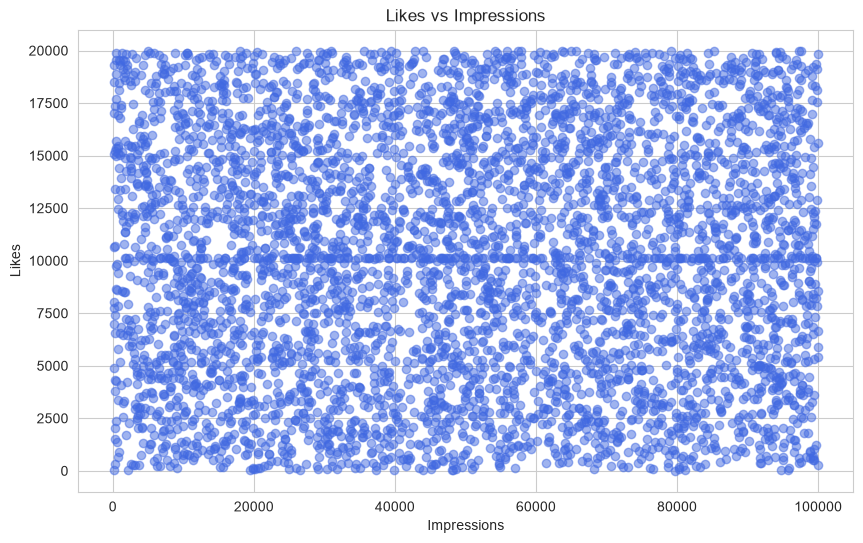

In [360]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["impression_count"],
    df["likes"],
    alpha=0.5,
    color="royalblue"
)

plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Likes vs Impressions")

plt.show()


In [361]:
daily_engagement = (
    df.groupby(df["posted_at"].dt.date)["engagement_score"]
    .mean()
    .reset_index()
)

daily_engagement.columns = ["posted_at", "average_engagement"]


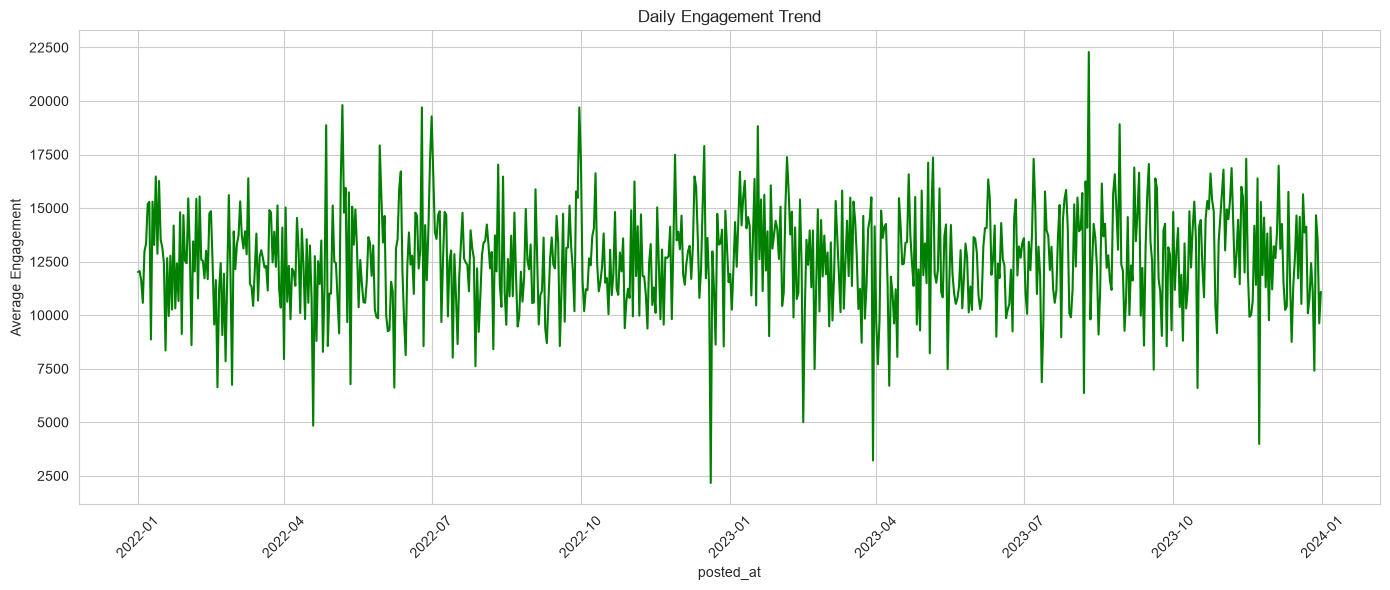

In [362]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_engagement["posted_at"],
    daily_engagement["average_engagement"],
    color="green"
)

plt.xlabel("posted_at")
plt.ylabel("Average Engagement")
plt.title("Daily Engagement Trend")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


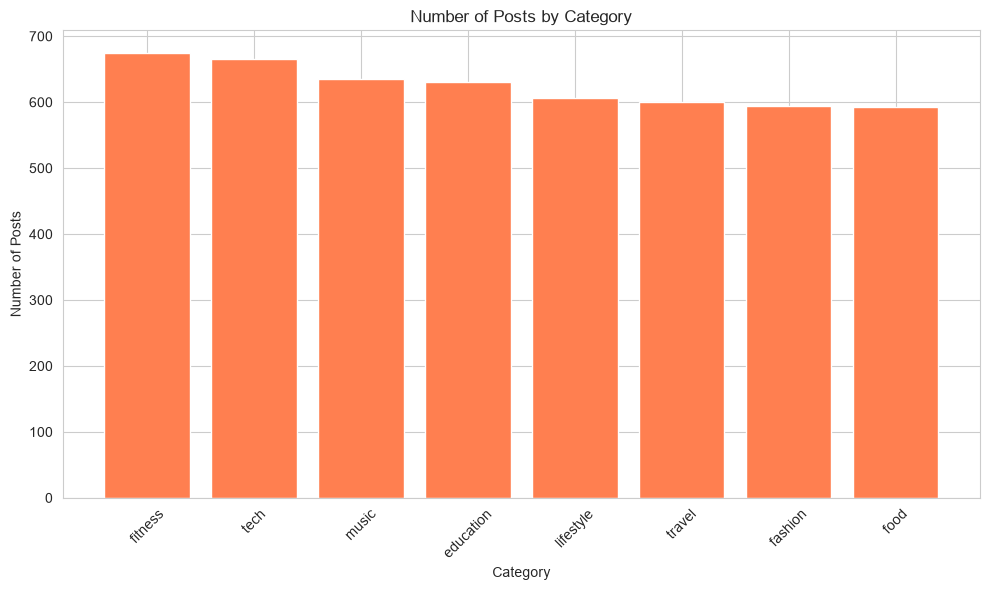

In [363]:
category_counts = df["post_category"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values,
    color="coral"
)

plt.xlabel("Category")
plt.ylabel("Number of Posts")
plt.title("Number of Posts by Category")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


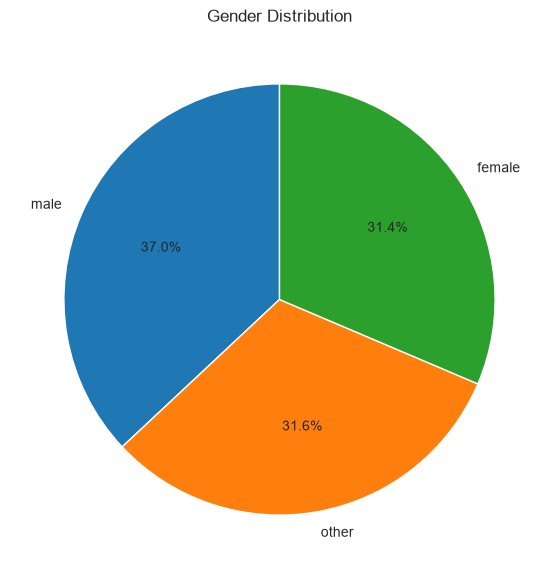

In [364]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()


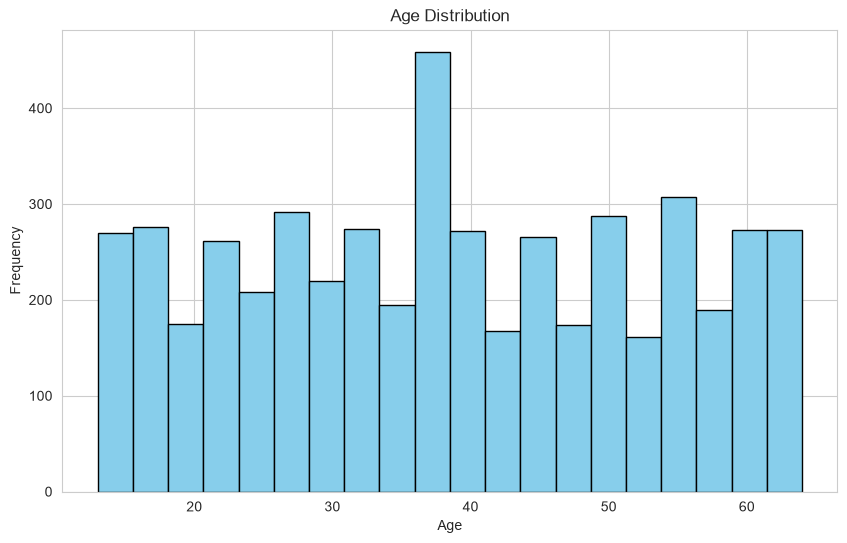

In [365]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["age"],
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()


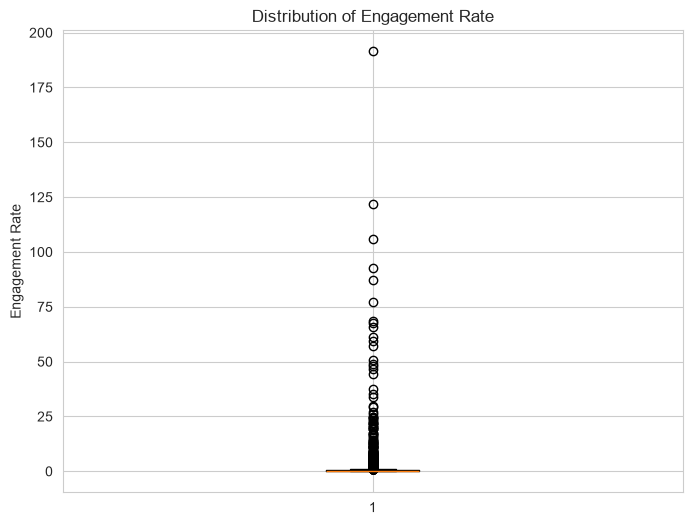

In [366]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    df["engagement_rate"].dropna()
)

plt.ylabel("Engagement Rate")
plt.title("Distribution of Engagement Rate")

plt.show()


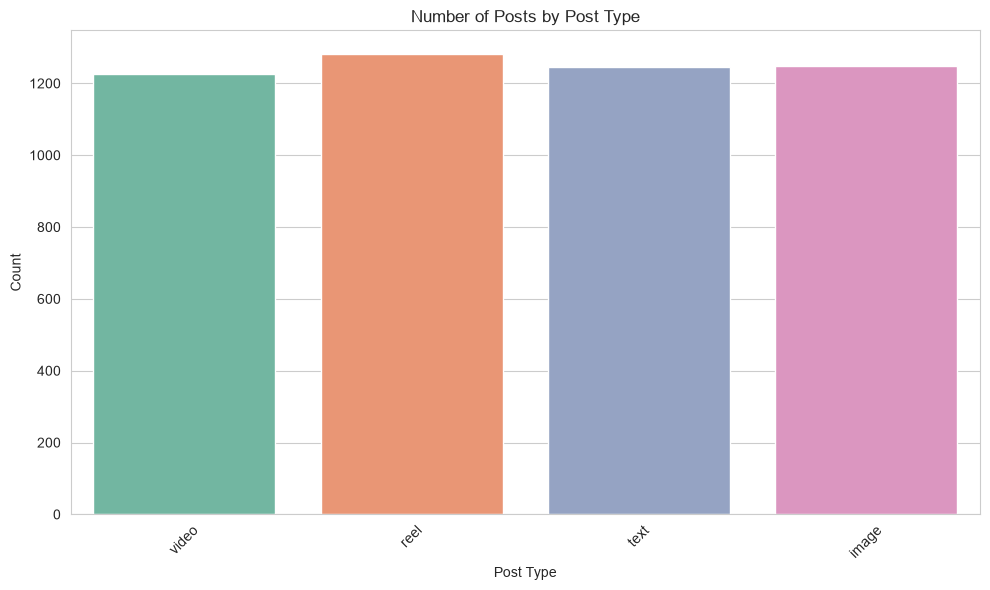

In [367]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="post_type",
    palette="Set2"
)

plt.title("Number of Posts by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


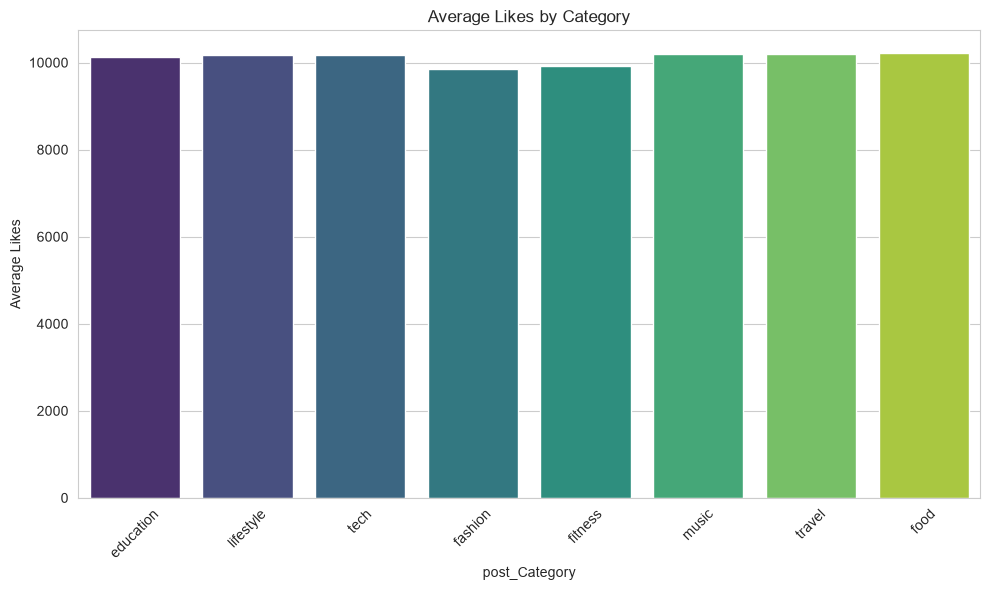

In [368]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    estimator=np.mean,
    errorbar=None,
    palette="viridis"
)

plt.title("Average Likes by Category")
plt.xlabel("post_Category")
plt.ylabel("Average Likes")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


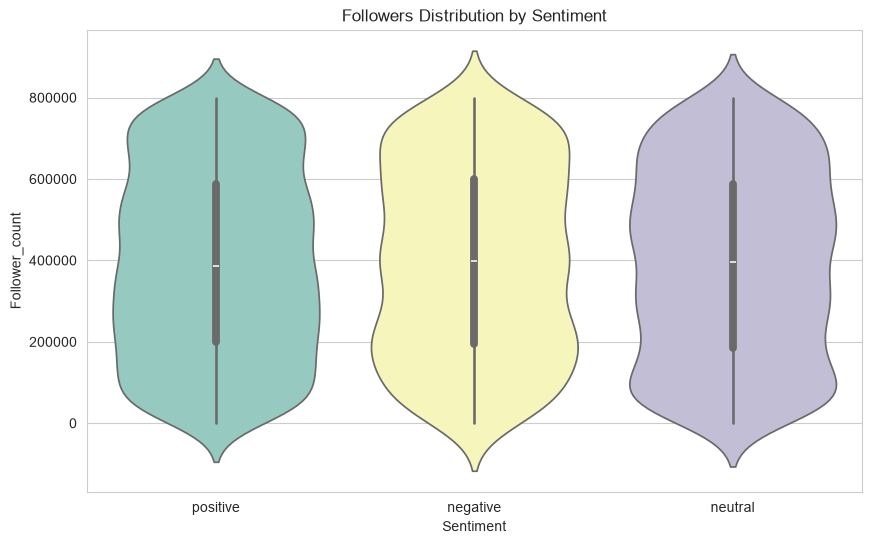

In [369]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count",
    palette="Set3"
)

plt.title("Followers Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Follower_count")

plt.show()


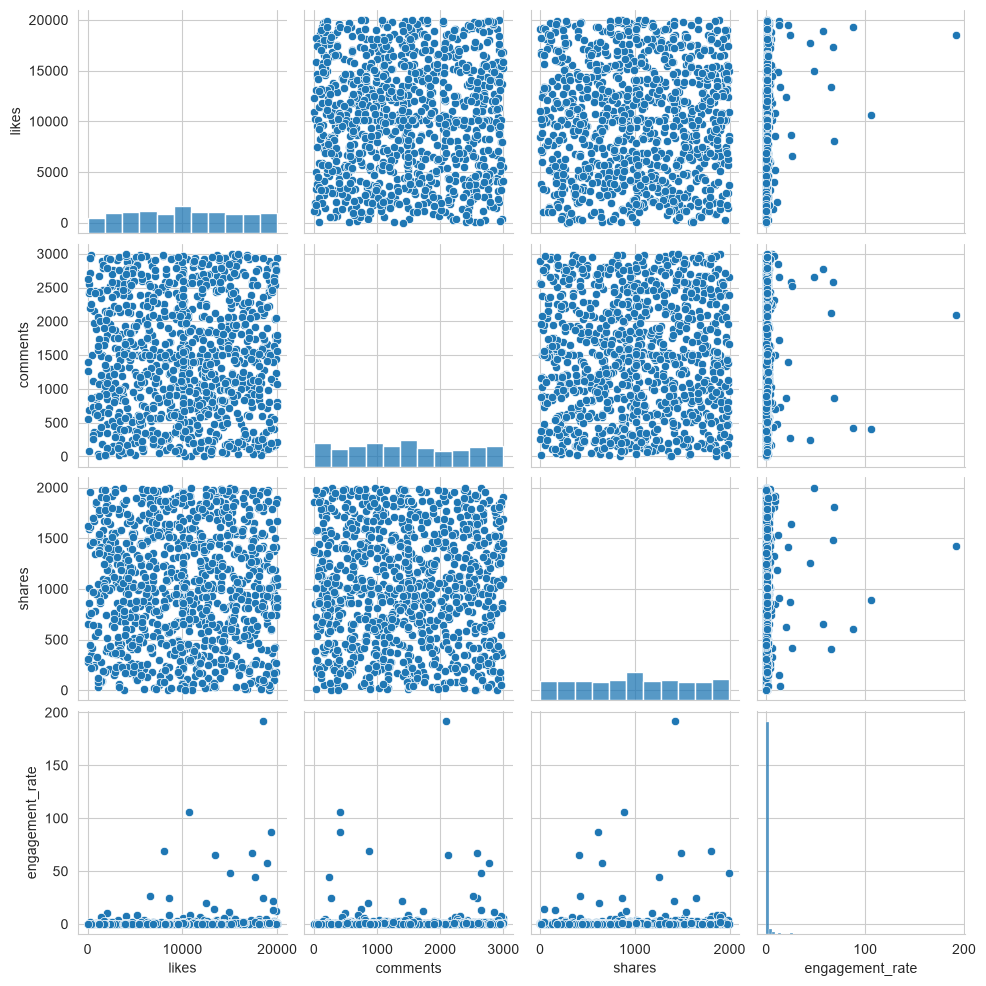

In [370]:
pair_columns = [
    "likes",
    "comments",
    "shares",
    "impressions",
    "engagement_rate"
]

pair_columns = [c for c in pair_columns if c in df.columns]

sns.pairplot(
    df[pair_columns].sample(
        min(1000, len(df)),
        random_state=42
    )
)

plt.show()


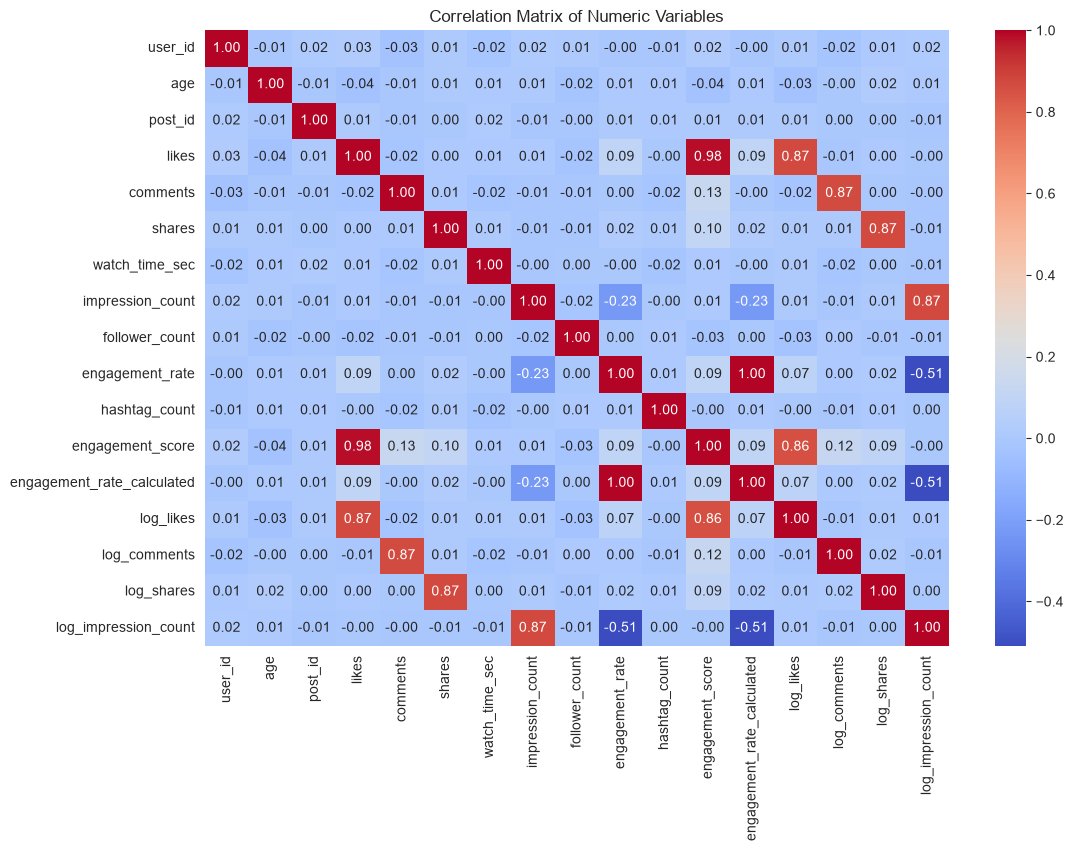

In [371]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numeric Variables")

plt.show()


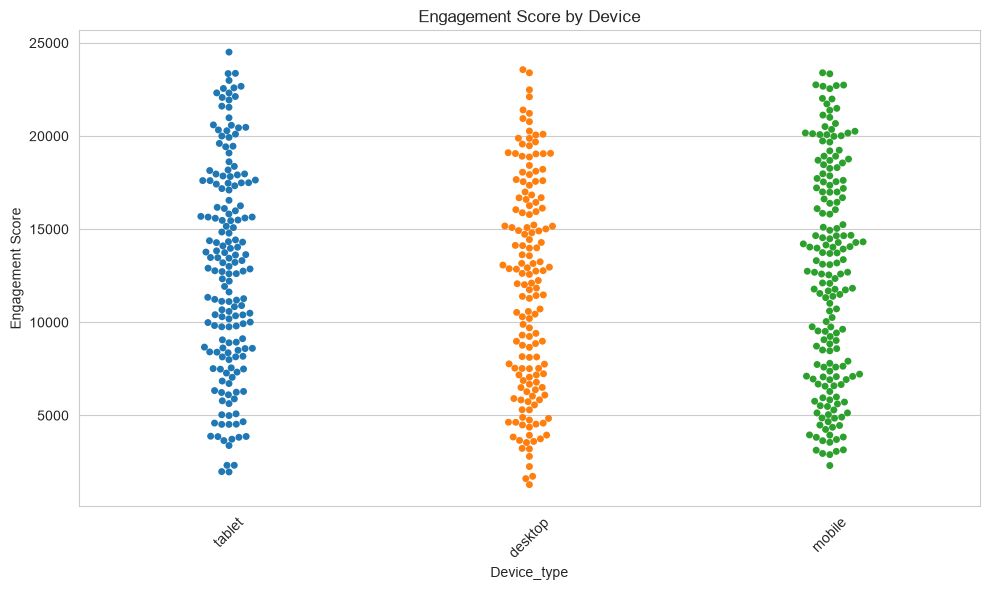

In [372]:
swarm_data = df.sample(
    min(500, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=swarm_data,
    x="device_type",
    y="engagement_score",
    hue="device_type",
    legend=False
)

plt.title("Engagement Score by Device")
plt.xlabel("Device_type")
plt.ylabel("Engagement Score")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [373]:
daily_plot = (
    df.groupby(df["posted_at"].dt.date)
    .agg(
        engagement_score=("engagement_score", "mean"),
        impression_count=("impression_count", "mean")
    )
    .reset_index()
)

fig = px.line(
    daily_plot,
    x="posted_at",
    y="engagement_score",
    title="Interactive Daily Engagement Trend",
    markers=True
)

fig.show()


In [374]:
category_interactive = (
    df.groupby("post_category")
    .agg(
        avg_likes=("likes", "mean"),
        avg_engagement=("engagement_score", "mean")
    )
    .reset_index()
)

fig = px.bar(
    category_interactive,
    x="post_category",
    y="avg_engagement",
    color="post_category",
    title="Average Engagement by Category"
-)

fig.show()


SyntaxError: invalid syntax (1367895199.py, line 16)

In [ ]:
fig = px.scatter(
    df.sample(min(2000, len(df)), random_state=42),
    x="impression_count",
    y="likes",
    size="comments",
    color="sentiment",
    hover_data=["post_type", "country"],
    title="Interactive Social Media Engagement Analysis"
)

fig.show()


In [ ]:
post_type_performance = (
    df.groupby("post_type")
    .agg(
        average_engagement=("engagement_score", "mean"),
        average_likes=("likes", "mean"),
        average_comments=("comments", "mean"),
        average_shares=("shares", "mean"),
        average_engagement_rate=("engagement_rate", "mean")
    )
    .sort_values("average_engagement", ascending=False)
)

post_type_performance.round(2)


,average_engagement,average_likes,average_comments,average_shares,average_engagement_rate
post_type,,,,,
video,12664.59,10188.60,1479.16,996.83,1.12
image,12649.39,10104.87,1525.24,1019.29,0.90
text,12613.24,10100.15,1499.11,1013.99,1.06
reel,12524.03,10037.80,1504.19,982.04,0.78


In [ ]:
top_post_type = post_type_performance.index[0]

print("Highest observed average engagement post type:", top_post_type)


Highest observed average engagement post type: video


In [ ]:
category_performance = (
    df.groupby("post_category")
    .agg(
        average_engagement=("engagement_score", "mean"),
        average_likes=("likes", "mean"),
        average_shares=("shares", "mean"),
        average_engagement_rate=("engagement_rate", "mean")
    )
    .sort_values("average_engagement", ascending=False)
)

category_performance.round(2)


,average_engagement,average_likes,average_shares,average_engagement_rate
post_category,,,,
music,12788.55,10205.75,1024.09,0.89
food,12739.20,10225.52,1002.80,1.36
tech,12686.49,10171.57,1009.37,1.16
travel,12650.56,10196.30,968.31,0.70
lifestyle,12639.54,10180.56,991.14,1.09
education,12578.27,10126.49,996.45,0.84
fitness,12457.79,9914.60,1042.05,0.87
fashion,12356.42,9843.36,982.52,0.81


In [ ]:
best_category = category_performance.index[0]

print("Highest observed average engagement category:", best_category)


Highest observed average engagement category: music


In [ ]:
country_performance = (
    df.groupby("country")
    .agg(
        average_engagement_rate=("engagement_rate", "mean"),
        average_engagement=("engagement_score", "mean"),
        average_likes=("likes", "mean")
    )
    .sort_values(
        "average_engagement_rate",
        ascending=False
    )
)

country_performance.round(2)


,average_engagement_rate,average_engagement,average_likes
country,,,
Brazil,1.54,12385.98,9886.69
Australia,1.32,12809.62,10294.12
France,1.15,12903.38,10372.88
UAE,1.11,12757.78,10227.49
Canada,0.92,12605.89,10063.07
UK,0.85,12384.37,9935.65
Japan,0.77,12578.65,10088.86
Germany,0.76,12635.66,10130.46
India,0.66,12492.70,9962.47


In [ ]:
country_performance.head(10)


,average_engagement_rate,average_engagement,average_likes
country,,,
Brazil,1.540704,12385.983135,9886.689484
Australia,1.324339,12809.621704,10294.124746
France,1.146402,12903.384073,10372.876008
UAE,1.112352,12757.777336,10227.487078
Canada,0.916659,12605.894737,10063.066277
UK,0.850966,12384.374239,9935.650101
Japan,0.769623,12578.648305,10088.862288
Germany,0.759000,12635.664286,10130.458163
India,0.655005,12492.701869,9962.468224


In [ ]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=[
        "Under 18",
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)


In [ ]:
age_engagement = (
    df.groupby("age_group", observed=True)
    .agg(
        average_engagement=("engagement_score", "mean"),
        average_engagement_rate=("engagement_rate", "mean"),
        users=("age", "count")
    )
)

age_engagement


,average_engagement,average_engagement_rate,users
age_group,,,
Under 18,12991.711538,0.867038,546
18-25,12628.408385,1.059536,644
26-35,12768.703874,0.865316,981
36-45,12741.579461,0.860741,1076
46-55,12373.489663,1.414058,919
56-65,12261.744005,0.709213,834


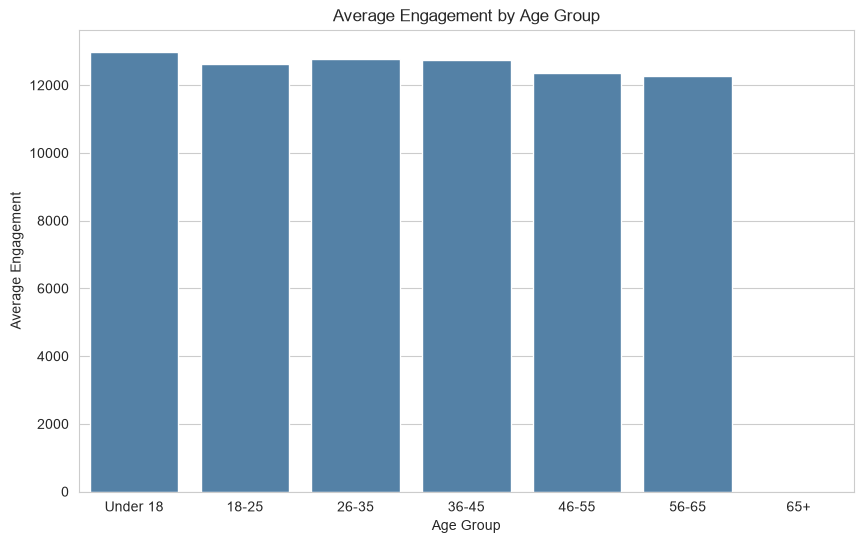

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_engagement.reset_index(),
    x="age_group",
    y="average_engagement",
    color="steelblue"
)

plt.title("Average Engagement by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Engagement")

plt.show()


In [ ]:
df["is_verified"].value_counts()


is_verified
False    4517
True      483
Name: count, dtype: int64

In [ ]:
verified_analysis = (
    df.groupby("is_verified")
    .agg(
        average_likes=("likes", "mean"),
        average_comments=("comments", "mean"),
        average_shares=("shares", "mean"),
        average_engagement=("engagement_score", "mean"),
        average_engagement_rate=("engagement_rate", "mean"),
        average_impressions=("impression_count", "mean")
    )
)

verified_analysis.round(2)


,average_likes,average_comments,average_shares,average_engagement,average_engagement_rate,average_impressions
is_verified,,,,,,
False,10137.20,1505.51,1001.60,12644.31,0.95,49935.29
True,9824.53,1469.57,1015.17,12309.28,1.05,50747.34


In [375]:
df['posted_at'] = pd.to_datetime(df['posted_at'],errors ='coerce')

In [376]:
df["hour"] = df["posted_at"].dt.hour


In [377]:
hourly_impressions = (
    df.groupby("hour")["impression_count"]
    .mean()
    .reindex(range(24))
)

print(hourly_impressions)


hour
0     50013.7328
1            NaN
2            NaN
3            NaN
4            NaN
5            NaN
6            NaN
7            NaN
8            NaN
9            NaN
10           NaN
11           NaN
12           NaN
13           NaN
14           NaN
15           NaN
16           NaN
17           NaN
18           NaN
19           NaN
20           NaN
21           NaN
22           NaN
23           NaN
Name: impression_count, dtype: float64


In [378]:
best_hour = hourly_impressions.idxmax()

print("Hour with highest average impressions:", best_hour)


Hour with highest average impressions: 0


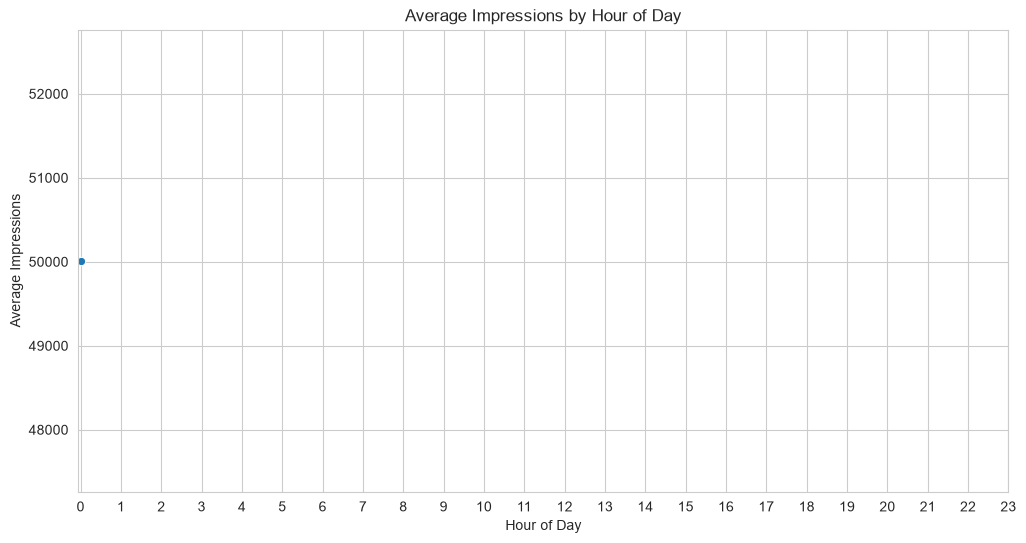

In [381]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_impressions.index,
    y=hourly_impressions.values,
    marker="o"
)

plt.title("Average Impressions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Impressions")

plt.xticks(range(24))
plt.grid(True)
plt.show()


In [384]:
device_watch_time = (
    df.groupby("device_type")
    .agg(
        average_watch_time=("watch_time_sec", "mean"),
        median_watch_time=("watch_time_sec", "median"),
        average_engagement=("engagement_score", "mean")
    )
    .sort_values("average_watch_time", ascending=False)
)

device_watch_time.round(2)


,average_watch_time,median_watch_time,average_engagement
device_type,,,
mobile,4087.83,4111.0,12663.19
tablet,3979.74,4072.0,12463.28
desktop,3974.79,3922.0,12708.56


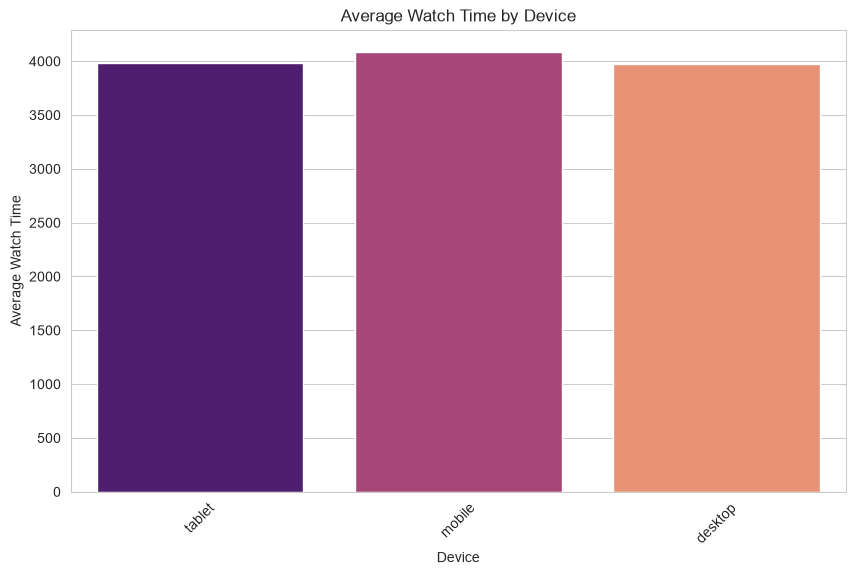

In [385]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="device_type",
    y="watch_time_sec",
    estimator=np.mean,
    errorbar=None,
    palette="magma"
)

plt.title("Average Watch Time by Device")
plt.xlabel("Device")
plt.ylabel("Average Watch Time")

plt.xticks(rotation=45)
plt.show()


In [387]:
sentiment_performance = (
    df.groupby("sentiment")
    .agg(
        average_likes=("likes", "mean"),
        average_comments=("comments", "mean"),
        average_shares=("shares", "mean"),
        average_engagement=("engagement_score", "mean"),
        average_engagement_rate=("engagement_rate", "mean"),
        average_impressions=("impression_count", "mean")
    )
    .sort_values("average_engagement", ascending=False)
)

sentiment_performance.round(2)


,average_likes,average_comments,average_shares,average_engagement,average_engagement_rate,average_impressions
sentiment,,,,,,
negative,10208.10,1516.09,1007.31,12731.50,1.04,50191.96
positive,10180.06,1480.65,1005.09,12665.80,0.92,50248.11
neutral,9923.19,1528.40,996.57,12448.16,0.99,49515.97


In [388]:
best_sentiment = sentiment_performance.index[0]

print("Highest observed average engagement sentiment:", best_sentiment)


Highest observed average engagement sentiment: negative


In [389]:
negative_neutral = (
    df[df["sentiment"].isin(["negative", "neutral"])]
    .groupby("sentiment")
    .agg(
        posts=("sentiment", "size"),
        average_likes=("likes", "mean"),
        average_comments=("comments", "mean"),
        average_shares=("shares", "mean"),
        average_engagement=("engagement_score", "mean"),
        average_engagement_rate=("engagement_rate", "mean"),
        average_impressions=("impression_count", "mean")
    )
)

negative_neutral.round(2)


,posts,average_likes,average_comments,average_shares,average_engagement,average_engagement_rate,average_impressions
sentiment,,,,,,,
negative,960,10208.10,1516.09,1007.31,12731.50,1.04,50191.96
neutral,1527,9923.19,1528.40,996.57,12448.16,0.99,49515.97


In [390]:
final_summary = pd.DataFrame({
    "Analysis": [
        "Top Post Type",
        "Top Category",
        "Top Country by Engagement Rate",
        "Top Sentiment",
        "Highest Impression Hour"
    ],
    "Result": [
        post_type_performance.index[0],
        category_performance.index[0],
        country_performance.index[0],
        sentiment_performance.index[0],
        hourly_impressions.index[0]
    ]
})

final_summary


,Analysis,Result
0,Top Post Type,video
1,Top Category,music
2,Top Country by Engagement Rate,Brazil
3,Top Sentiment,negative
4,Highest Impression Hour,0
